In [19]:
# Sentiment Analysis (How customers feel?)

# Using DistilBERT AI model

import os
import warnings
import pandas as pd
from tqdm.notebook import tqdm

# Mute standard Python warnings and Hugging Face symlink warnings
warnings.filterwarnings("ignore")
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

# Load the copy of the clean, processed data directly from project folder

# 1. Define the path to the processed data file
processed_data_path = r'C:\Users\nemsa\KAIM Challenge Project\Fintech-Review-Analytics\data\processed\combined_bank_reviews_cleaned.csv'

# 2. Read the file into memory and immediately make an isolated copy
if os.path.exists(processed_data_path):
    df_raw = pd.read_csv(processed_data_path)
    df_clean = df_raw.copy()  # Safe copy for sentiment analysis
    print(f"✅ Successfully loaded {len(df_clean)} reviews from CSV!")
else:
    print(f"❌ Error: File not found at {processed_data_path}. Please check the path or run your scraping notebook first.")

try:
    from transformers import pipeline
    print("\n🔄 Loading DistilBERT Model (This may take a moment on the first run)...")
    sent_model = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")
    print("✅ Model loaded successfully!")

    # 1. Process all reviews at once for speed efficiency
    transformer_results = []
    batch_size = 16 
    
    for i in tqdm(range(0, len(df_clean), batch_size), desc="Running DistilBERT Pipeline"):
        batch = df_clean['review'].iloc[i:i + batch_size].tolist()
        preds = sent_model(batch)
        transformer_results.extend(preds)

# 2. Injected Custom Logic to Determine Neutrality
    # Threshold = 0.70. If confidence is below 70%, re-classify it as NEUTRAL.
    neutral_threshold = 0.70
    
    final_labels = []
    final_scores = []
    
    for p in transformer_results:
        raw_label = p['label']
        confidence = p['score']
        
        if confidence < neutral_threshold:
            final_labels.append('NEUTRAL')
            final_scores.append(0.0) # Neutral sits right at zero
        else:
            final_labels.append(raw_label)
            # Maintain the mathematical mapping: Positive is (+), Negative is (-)
            final_scores.append(confidence if raw_label == 'POSITIVE' else -confidence)

    # Assign updated lists to main dataframe columns
    df_clean['transformer_sentiment_label'] = final_labels
    df_clean['transformer_sentiment_score'] = final_scores

    # 3. ITERATE to compare distributions per bank
    print("\n" + "=" * 60)
    print(" SENTIMENT DISTRIBUTION COMPARISON BY BANK")
    print("=" * 60)
    
    # Get unique bank names dynamically present in the data
    target_banks = df_clean['bank'].unique()
    
    for bank in target_banks:
        # Isolate rows belonging only to the current bank
        df_bank = df_clean[df_clean['bank'] == bank]

        print(f"\n🏢 {bank.upper()}:")
        print(f"Total Cleaned Reviews: {len(df_bank)}")
        
        # Calculate raw counts and raw percentages
        counts = df_bank['transformer_sentiment_label'].value_counts()
        percentages = df_bank['transformer_sentiment_label'].value_counts(normalize=True) * 100
        
        # Print breakdown cleanly
        for label in ['POSITIVE', 'NEUTRAL', 'NEGATIVE']:
            cnt = counts.get(label, 0)
            pct = percentages.get(label, 0.0)

            # Choose color blocks for visual styling
            if label == 'POSITIVE': bar = '🟩'
            elif label == 'NEUTRAL': bar = '🟨'
            else: bar = '🟥'

            bar_visual = bar * int(pct // 5) # Generates an inline comparative bar chart
            print(f"  {label:<10} : {cnt:>4} records ({pct:>5.1f}%)  {bar_visual}")
        
        # Calculate the average sentiment intensity score
        avg_score = df_bank['transformer_sentiment_score'].mean()
        print(f"  Average Sentiment Score (-1 to +1): {avg_score:.2f}")
        print("-" * 45)

except Exception as e:
    print(f"Transformer processing failed: {e}")

✅ Successfully loaded 1200 reviews from CSV!

🔄 Loading DistilBERT Model (This may take a moment on the first run)...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✅ Model loaded successfully!


Running DistilBERT Pipeline:   0%|          | 0/75 [00:00<?, ?it/s]


 SENTIMENT DISTRIBUTION COMPARISON BY BANK

🏢 COMMERCIAL BANK OF ETHIOPIA:
Total Cleaned Reviews: 400
  POSITIVE   :  215 records ( 53.8%)  🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩
  NEUTRAL    :    2 records (  0.5%)  
  NEGATIVE   :  183 records ( 45.8%)  🟥🟥🟥🟥🟥🟥🟥🟥🟥
  Average Sentiment Score (-1 to +1): 0.08
---------------------------------------------

🏢 BANK OF ABYSSINIA:
Total Cleaned Reviews: 400
  POSITIVE   :  129 records ( 32.2%)  🟩🟩🟩🟩🟩🟩
  NEUTRAL    :    7 records (  1.8%)  
  NEGATIVE   :  264 records ( 66.0%)  🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥🟥
  Average Sentiment Score (-1 to +1): -0.33
---------------------------------------------

🏢 DASHEN BANK:
Total Cleaned Reviews: 400
  POSITIVE   :  235 records ( 58.8%)  🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩
  NEUTRAL    :    2 records (  0.5%)  
  NEGATIVE   :  163 records ( 40.8%)  🟥🟥🟥🟥🟥🟥🟥🟥
  Average Sentiment Score (-1 to +1): 0.18
---------------------------------------------


In [20]:
# Using VADER and TextBlob Sentiment Analyzers

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

# Initialize VADER Sentiment Analyzer
sia = SentimentIntensityAnalyzer()

# 1. Apply baseline VADER and TextBlob metrics across the master copy
df_clean['vader_compound'] = df_clean['review'].apply(lambda x: sia.polarity_scores(str(x))['compound'])
df_clean['tb_polarity'] = df_clean['review'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
df_clean['tb_subjectivity'] = df_clean['review'].apply(lambda x: TextBlob(str(x)).sentiment.subjectivity)

# 2. Define labeling logic functions for comparisons
def get_vader_label(score):
    return 'POSITIVE' if score >= 0.05 else ('NEGATIVE' if score <= -0.05 else 'NEUTRAL')

def get_tb_label(score):
    return 'POSITIVE' if score > 0.0 else ('NEGATIVE' if score < 0.0 else 'NEUTRAL')

# Assign explicit labels to the main dataframe
df_clean['vader_sentiment_label'] = df_clean['vader_compound'].apply(get_vader_label)
df_clean['tb_sentiment_label'] = df_clean['tb_polarity'].apply(get_tb_label)

# 3. ITERATE to compare rule-based distributions per bank
print("=" * 65)
print("  LEXICON SENTIMENT BREAKDOWN BY BANK (VADER vs TEXTBLOB)")
print("=" * 65)

target_banks = df_clean['bank'].unique()

for bank in target_banks:
    # Isolate rows belonging only to the current bank iteration
    df_bank = df_clean[df_clean['bank'] == bank]
    total_reviews = len(df_bank)
    
    print(f"\n🏢 {bank.upper()}")
    print(f"Total Evaluated Records: {total_reviews}")
    print("-" * 50)
    
    # --- VADER SIDE BREAKDOWN ---
    print("  [VADER Framework]")
    v_counts = df_bank['vader_sentiment_label'].value_counts()
    v_pct = df_bank['vader_sentiment_label'].value_counts(normalize=True) * 100
    
    for lbl in ['POSITIVE', 'NEUTRAL', 'NEGATIVE']:
        cnt = v_counts.get(lbl, 0)
        pct = v_pct.get(lbl, 0.0)
        print(f"    {lbl:<10} : {cnt:>4} records ({pct:>5.1f}%)")
    print(f"    Average VADER Compound Score: {df_bank['vader_compound'].mean():.3f}")
    
    print()
    
    # --- TEXTBLOB SIDE BREAKDOWN ---
    print("  [TEXTBLOB Framework]")
    tb_counts = df_bank['tb_sentiment_label'].value_counts()
    tb_pct = df_bank['tb_sentiment_label'].value_counts(normalize=True) * 100
    
    for lbl in ['POSITIVE', 'NEUTRAL', 'NEGATIVE']:
        cnt = tb_counts.get(lbl, 0)
        pct = tb_pct.get(lbl, 0.0)
        print(f"    {lbl:<10} : {cnt:>4} records ({pct:>5.1f}%)")
    print(f"    Average TextBlob Polarity : {df_bank['tb_polarity'].mean():.3f}")
    print(f"    Average Subjectivity Index: {df_bank['tb_subjectivity'].mean():.3f} (0=Fact, 1=Opinion)")
    
    print("=" * 65)


  LEXICON SENTIMENT BREAKDOWN BY BANK (VADER vs TEXTBLOB)

🏢 COMMERCIAL BANK OF ETHIOPIA
Total Evaluated Records: 400
--------------------------------------------------
  [VADER Framework]
    POSITIVE   :  229 records ( 57.2%)
    NEUTRAL    :   82 records ( 20.5%)
    NEGATIVE   :   89 records ( 22.2%)
    Average VADER Compound Score: 0.207

  [TEXTBLOB Framework]
    POSITIVE   :  232 records ( 58.0%)
    NEUTRAL    :  100 records ( 25.0%)
    NEGATIVE   :   68 records ( 17.0%)
    Average TextBlob Polarity : 0.249
    Average Subjectivity Index: 0.474 (0=Fact, 1=Opinion)

🏢 BANK OF ABYSSINIA
Total Evaluated Records: 400
--------------------------------------------------
  [VADER Framework]
    POSITIVE   :  175 records ( 43.8%)
    NEUTRAL    :  103 records ( 25.8%)
    NEGATIVE   :  122 records ( 30.5%)
    Average VADER Compound Score: 0.072

  [TEXTBLOB Framework]
    POSITIVE   :  193 records ( 48.2%)
    NEUTRAL    :  106 records ( 26.5%)
    NEGATIVE   :  101 records ( 25.2%

In [21]:
# Comparing Sentiment Distributions 

# Check if prior processing columns exist in df_clean
required_cols = ['vader_sentiment_label', 'tb_polarity', 'transformer_sentiment_label']
missing_cols = [col for col in required_cols if col not in df_clean.columns]

if missing_cols:
    print(f"❌ Cannot compare distributions. Missing calculated columns: {missing_cols}")
else:
    print("=" * 70)
    # Mapping function to make sure TextBlob shares the exact same label strings
    def get_tb_label(s):
        return 'POSITIVE' if s >= 0.05 else ('NEGATIVE' if s <= -0.05 else 'NEUTRAL')

    # Ensure all the framework columns use identical casing for clean formatting
    df_clean['vader_label_upper'] = df_clean['vader_sentiment_label'].str.upper()
    df_clean['tb_label_upper'] = df_clean['tb_polarity'].apply(get_tb_label)
    df_clean['trans_label_upper'] = df_clean['transformer_sentiment_label'].str.upper()

    # Loop through each bank dynamically present in the dataset
    target_banks = df_clean['bank'].unique()

    for bank in target_banks:
        df_bank = df_clean[df_clean['bank'] == bank]
        total_reviews = len(df_bank)
        
        print(f"\n🏢 SENTIMENT FRAMEWORK COMPARISON FOR: {bank.upper()}")
        print(f"📊 Dataset Size: {total_reviews} reviews")
        print("-" * 70)
        
        # Build a comparative distribution DataFrame for this specific bank
        vader_dist = df_bank['vader_label_upper'].value_counts(normalize=True).round(2)
        textblob_dist = df_bank['tb_label_upper'].value_counts(normalize=True).round(2)
        trans_dist = df_bank['trans_label_upper'].value_counts(normalize=True).round(2)
        
        # Combine them into a single summary table for side-by-side inspection
        comparison_df = pd.DataFrame({
            'VADER': vader_dist,
            'TextBlob': textblob_dist,
            'DistilBERT (Transformer)': trans_dist
        }).fillna(0.0) # Fills missing structural label values with 0.0 if a category isn't guessed
        
        # Re-index rows to maintain a consistent logical order
        comparison_df = comparison_df.reindex(['POSITIVE', 'NEUTRAL', 'NEGATIVE'])
        
        # Print the side-by-side distribution matrix
        print(comparison_df)
        print("=" * 70)


🏢 SENTIMENT FRAMEWORK COMPARISON FOR: COMMERCIAL BANK OF ETHIOPIA
📊 Dataset Size: 400 reviews
----------------------------------------------------------------------
          VADER  TextBlob  DistilBERT (Transformer)
POSITIVE   0.57      0.57                      0.54
NEUTRAL    0.20      0.27                      0.00
NEGATIVE   0.22      0.16                      0.46

🏢 SENTIMENT FRAMEWORK COMPARISON FOR: BANK OF ABYSSINIA
📊 Dataset Size: 400 reviews
----------------------------------------------------------------------
          VADER  TextBlob  DistilBERT (Transformer)
POSITIVE   0.44      0.46                      0.32
NEUTRAL    0.26      0.30                      0.02
NEGATIVE   0.30      0.24                      0.66

🏢 SENTIMENT FRAMEWORK COMPARISON FOR: DASHEN BANK
📊 Dataset Size: 400 reviews
----------------------------------------------------------------------
          VADER  TextBlob  DistilBERT (Transformer)
POSITIVE   0.65      0.66                      0.59
NEUTRAL 

📊 Aggregating sentiment matrices grouped by [bank] and [rating]...

--- 📈 AVERAGE VADER COMPOUND SCORE MATRIX ---


rating,1,2,3,4,5
bank,,,,,
Bank of Abyssinia,-0.209463,-0.011539,0.178888,0.394052,0.396906
Commercial Bank of Ethiopia,-0.159162,0.064136,-0.086297,0.274746,0.443240
Dashen Bank,-0.174917,-0.042665,0.301237,0.381562,0.524957



--- 📈 AVERAGE TEXTBLOB POLARITY MATRIX ---


rating,1,2,3,4,5
bank,,,,,
Bank of Abyssinia,-0.133282,-0.010747,0.131892,0.354084,0.449667
Commercial Bank of Ethiopia,-0.089171,0.101496,0.091155,0.400459,0.435325
Dashen Bank,-0.192458,0.152365,0.182919,0.337078,0.462183



--- 📈 AVERAGE DISTILBERT TRANSFORMER MATRIX ---


rating,1,2,3,4,5
bank,,,,,
Bank of Abyssinia,-0.907718,-0.927241,-0.490830,-0.238181,0.552611
Commercial Bank of Ethiopia,-0.761644,-0.520108,-0.571774,0.023746,0.691687
Dashen Bank,-0.864145,-0.652641,-0.584776,-0.150760,0.811861


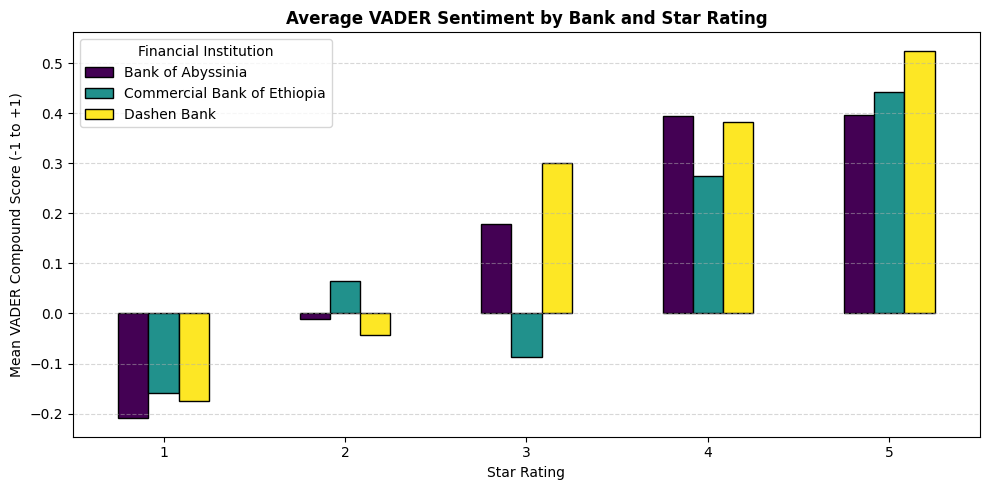

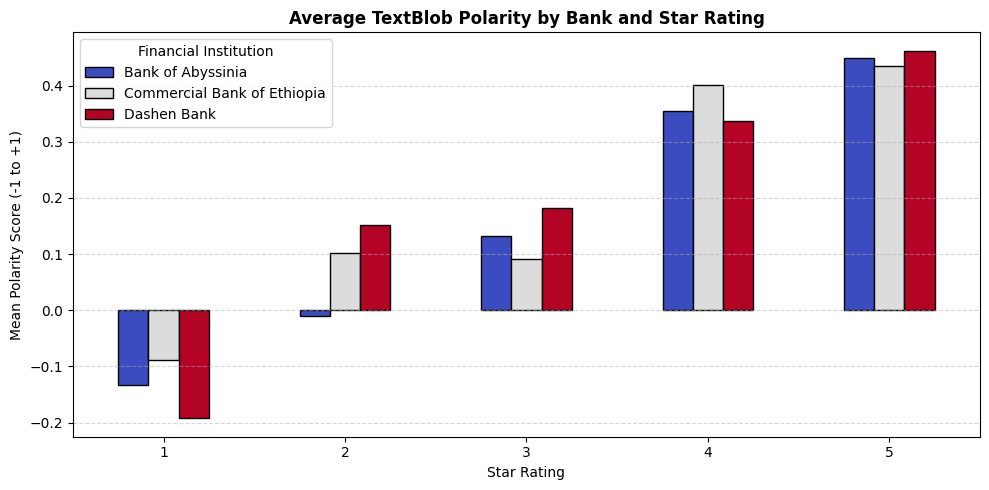

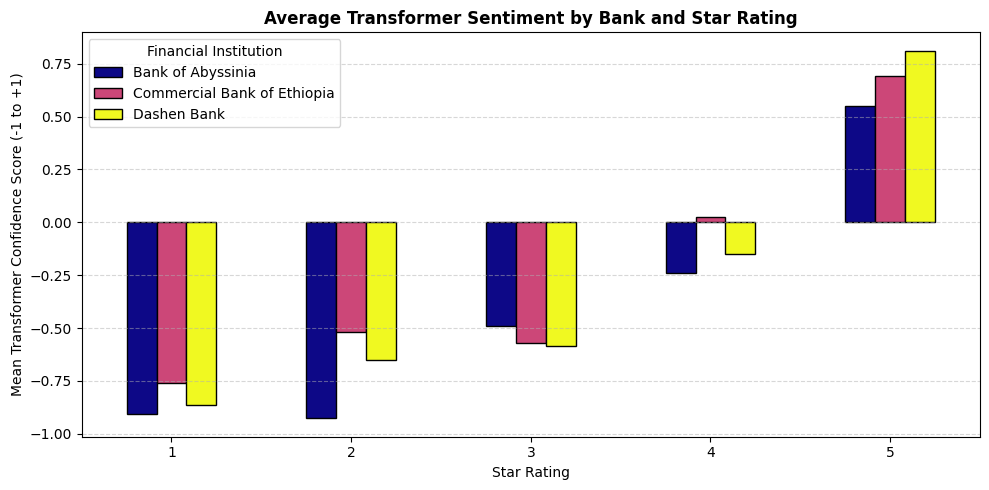

In [22]:
# Aggregate VADER sentiment scores by bank and star rating

import matplotlib.pyplot as plt
import pandas as pd

# Check column names to prevent runtime exceptions
group_col = 'bank' if 'bank' in df_clean.columns else 'app'
print(f"📊 Aggregating sentiment matrices grouped by [{group_col}] and [rating]...")

# ----------------------------------------------------------------------
# 1. MATHEMATICAL AGGREGATIONS
# ----------------------------------------------------------------------

# Aggregate VADER sentiment scores
vader_agg = df_clean.groupby([group_col, 'rating'])['vader_compound'].mean().unstack()
print("\n--- 📈 AVERAGE VADER COMPOUND SCORE MATRIX ---")
display(vader_agg)

# Aggregate TextBlob polarity scores
tb_agg = df_clean.groupby([group_col, 'rating'])['tb_polarity'].mean().unstack()
print("\n--- 📈 AVERAGE TEXTBLOB POLARITY MATRIX ---")
display(tb_agg)

# Aggregate Transformer sentiment scores
trans_agg = df_clean.groupby([group_col, 'rating'])['transformer_sentiment_score'].mean().unstack()
print("\n--- 📈 AVERAGE DISTILBERT TRANSFORMER MATRIX ---")
display(trans_agg)

# ----------------------------------------------------------------------
# 2. DATA VISUALIZATION GENERATION
# ----------------------------------------------------------------------

# Chart 1: VADER Sentiment by Bank and Rating
vader_agg.T.plot(kind='bar', figsize=(10, 5), colormap='viridis', edgecolor='black')
plt.title('Average VADER Sentiment by Bank and Star Rating', fontsize=12, fontweight='bold')
plt.xlabel('Star Rating', fontsize=10)
plt.ylabel('Mean VADER Compound Score (-1 to +1)', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=0)
plt.legend(title='Financial Institution')
plt.tight_layout()
plt.show()

# Chart 2: TextBlob Sentiment by Bank and Rating
tb_agg.T.plot(kind='bar', figsize=(10, 5), colormap='coolwarm', edgecolor='black')
plt.title('Average TextBlob Polarity by Bank and Star Rating', fontsize=12, fontweight='bold')
plt.xlabel('Star Rating', fontsize=10)
plt.ylabel('Mean Polarity Score (-1 to +1)', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=0)
plt.legend(title='Financial Institution')
plt.tight_layout()
plt.show()

# Chart 3: Transformer Sentiment by Bank and Rating
trans_agg.T.plot(kind='bar', figsize=(10, 5), colormap='plasma', edgecolor='black')
plt.title('Average Transformer Sentiment by Bank and Star Rating', fontsize=12, fontweight='bold')
plt.xlabel('Star Rating', fontsize=10)
plt.ylabel('Mean Transformer Confidence Score (-1 to +1)', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=0)
plt.legend(title='Financial Institution')
plt.tight_layout()
plt.show()

🔍 Extracting top keywords per bank using TF-IDF...

🔝 Top Keywords for COMMERCIAL BANK OF ETHIOPIA:
app, application, bank, best, cbe, easy, fast, fix, good, like, make, mobile, new, nice, service

🔝 Top Keywords for BANK OF ABYSSINIA:
app, application, bank, banking, best, boa, developer, doesn, don, fix, good, mobile, mobile banking, money, time

🔝 Top Keywords for DASHEN BANK:
app, bank, banking, best, dashen, dashen bank, easy, easy use, fast, friendly, good, great, mobile, need, super


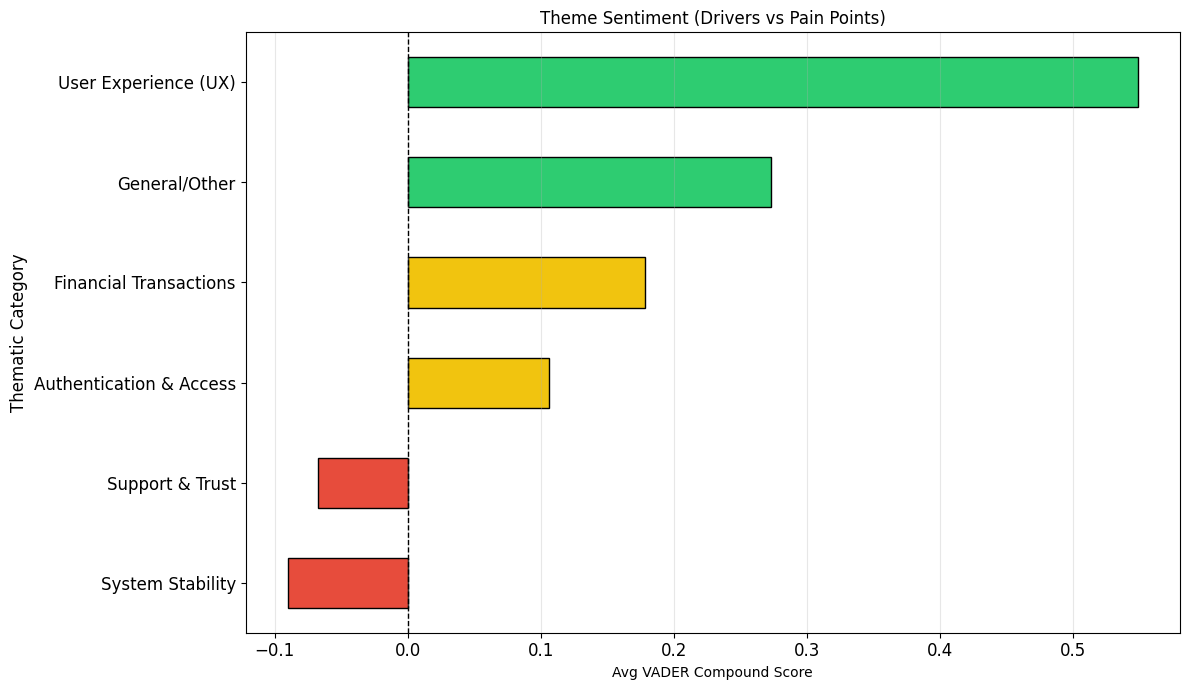


📊 Theme Distribution per Bank:


theme,Authentication & Access,Financial Transactions,General/Other,Support & Trust,System Stability,User Experience (UX)
bank,,,,,,
Bank of Abyssinia,6.0,5.0,52.0,11.0,21.0,4.0
Commercial Bank of Ethiopia,5.0,10.0,56.0,8.0,13.0,8.0
Dashen Bank,9.0,4.0,52.0,6.0,15.0,14.0


In [24]:
# Thematic Analysis (Why customers feel that way?)

# Thematic Discovery and Mapping
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import matplotlib.pyplot as plt

# 1) KEYWORD DISCOVERY (TF-IDF)
# Let's see what users are actually talking about for each bank
print("🔍 Extracting top keywords per bank using TF-IDF...")
vectorizer = TfidfVectorizer(max_features=20, stop_words='english', ngram_range=(1, 2))

for bank in df_clean['bank'].unique():
    bank_text = df_clean[df_clean['bank'] == bank]['review']
    tfidf_matrix = vectorizer.fit_transform(bank_text)
    features = vectorizer.get_feature_names_out()
    print(f"\n🔝 Top Keywords for {bank.upper()}:")
    print(", ".join(features[:15]))

# 2) DEFINING THE THEMES (Refined based on Ethiopian Fintech context)
THEME_MAP = {
    'System Stability': ['crash', 'freeze', 'bug', 'error', 'slow', 'stuck', 'failed', 'loading', 'working', 'network'],
    'Authentication & Access': ['login', 'otp', 'password', 'account', 'verify', 'sign', 'username', 'register', 'code'],
    'User Experience (UX)': ['ui', 'interface', 'clean', 'easy', 'navigation', 'design', 'beautiful', 'user friendly', 'smooth'],
    'Financial Transactions': ['transfer', 'payment', 'bill', 'card', 'wallet', 'money', 'transaction', 'balance', 'airtime'],
    'Support & Trust': ['customer', 'support', 'help', 'service', 'call', 'agent', 'worst', 'scam', 'poor']
}

def get_theme(txt):
    if not isinstance(txt, str): return 'Other'
    txt = txt.lower()
    for theme, keywords in THEME_MAP.items():
        if any(w in txt for w in keywords): 
            return theme
    return 'General/Other'

# 3) APPLYING THEMES
df_clean['theme'] = df_clean['review'].apply(get_theme)

# 4) VISUALIZATION: Theme Sentiment (Drivers vs. Pain Points)
theme_sent = df_clean.groupby('theme')['vader_compound'].mean().sort_values()

plt.figure(figsize=(12, 7))
# Dynamic coloring: Red for pain points, Green for drivers
colors = ['#e74c3c' if x < 0.05 else ('#2ecc71' if x > 0.2 else '#f1c40f') for x in theme_sent.values]

theme_sent.plot(kind='barh', color=colors, edgecolor='black', fontsize=12)
plt.ylabel('Thematic Category', fontsize=12)
plt.axvline(0, color='black', linestyle='--', lw=1)
plt.grid(axis='x', alpha=0.3)
plt.title('Theme Sentiment (Drivers vs Pain Points)')
plt.xlabel('Avg VADER Compound Score')
plt.tight_layout()
plt.show()

# 5) THEME DISTRIBUTION BY BANK
print("\n📊 Theme Distribution per Bank:")
theme_dist = pd.crosstab(df_clean['bank'], df_clean['theme'], normalize='index').round(2) * 100
display(theme_dist)

* 📊 Thematic Grouping Logic & Rationale

    To transform raw customer reviews into actionable business intelligence, keywords extracted via TF-IDF were categorized into five overarching domains. This grouping logic maps specific user feedback directly to structural layers of a digital banking product:

    * **System Stability (The Infrastructure Layer)**

        *Keywords*: crash, freeze, bug, error, slow, stuck, failed, loading, working, network

        *Rationale*: This maps backend infrastructure and network performance. In the Ethiopian fintech ecosystem, high-traffic periods often strain server capacity; tracking this theme isolates pure technical downtime from user-error issues.

    * **Authentication & Access (The Onboarding & Security Layer)**

        *Keywords*: login, otp, password, account, verify, sign, username, register, code

        *Rationale*: This focuses on security hurdles and entry barriers. SMS gateway delays for One-Time Passwords (OTPs) or credential lockouts are high-friction pain points that completely block users from interacting with the app.

    * **User Experience (UX) (The Front-End Layer)**

        *Keywords*: ui, interface, clean, easy, navigation, design, beautiful, user friendly, smooth

        *Rationale*: This captures the visual and interactive appeal of the application. Positive mentions here serve as brand loyalty drivers, while negative feedback highlights confusing navigation paths or unreadable text.

    * **Financial Transactions (The Core Utility Layer)**

        *Keywords*: transfer, payment, bill, card, wallet, money, transaction, balance, airtime

        *Rationale*: This evaluates whether the app is successfully performing its primary business tasks (e.g., peer-to-peer transfers, paying utility bills, airtime top-ups). This measures the core transactional utility of the platform.

    * **Support & Trust (The Service Layer)**

        *Keywords*: customer, support, help, service, call, agent, worst, scam, poor

        *Rationale*: This measures consumer sentiment regarding external assistance when digital systems fail. It highlights the human-to-digital interface, catching critical flags related to missing funds, lack of branch support, or perceived security fears.

In [26]:
# Saving results

import os
import pandas as pd
import spacy
from tqdm.notebook import tqdm
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# ----------------------------------------------------------------------
# 1. PIPELINE INITIALIZATION & NLP SETUP
# ----------------------------------------------------------------------
print("📥 Initializing NLP Pipeline Models...")
# Load lightweight spaCy model for tokenization, stop-word filtering, and lemmatization
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
sia = SentimentIntensityAnalyzer()

# Define the updated Business Theme dictionary matrix
THEME_MAP = {
    'System Stability': ['crash', 'freeze', 'bug', 'error', 'slow', 'stuck', 'failed', 'loading', 'working', 'network'],
    'Authentication & Access': ['login', 'otp', 'password', 'account', 'verify', 'sign', 'username', 'register', 'code'],
    'User Experience (UX)': ['ui', 'interface', 'clean', 'easy', 'navigation', 'design', 'beautiful', 'user friendly', 'smooth'],
    'Financial Transactions': ['transfer', 'payment', 'bill', 'card', 'wallet', 'money', 'transaction', 'balance', 'airtime'],
    'Support & Trust': ['customer', 'support', 'help', 'service', 'call', 'agent', 'worst', 'scam', 'poor']
}

# ----------------------------------------------------------------------
# 2. MODULAR TEXT PROCESSING FUNCTIONS
# ----------------------------------------------------------------------
def normalize_review_text(text, use_lemmatization=True):
    """
    Handles lowercasing, tokenization, stop-word removal, and optional lemmatization.
    """
    if not isinstance(text, str) or text.strip() == "":
        return ""
    
    # Process text through the spaCy pipeline
    doc = nlp(text.lower().strip())
    
    clean_tokens = []
    for token in doc:
        # Filter out punctuation, whitespace, and system stop-words
        if not token.is_punct and not token.is_space and not token.is_stop:
            if use_lemmatization:
                clean_tokens.append(token.lemma_) # Reduce words to root form (e.g., "crashing" -> "crash")
            else:
                clean_tokens.append(token.text)
                
    return " ".join(clean_tokens)

def get_theme_mapping(txt):
    """Maps review content to business domains based on heuristic keyword profiles"""
    if not isinstance(txt, str): return 'General/Other'
    txt = txt.lower()
    for theme, keywords in THEME_MAP.items():
        if any(w in txt for w in keywords): 
            return theme
    return 'General/Other'

# ----------------------------------------------------------------------
# 3. MAIN PIPELINE EXECUTION ENGINE
# ----------------------------------------------------------------------
def run_final_pipeline(df_input, output_filepath):
    print("\n🚀 Starting final compilation run...")
    df_pipeline = df_input.copy()
    
    # Ensure a proper unique identifier exists for your schemas
    if 'review_id' not in df_pipeline.columns:
        df_pipeline['review_id'] = [f"REV_{i:04d}" for i in range(len(df_pipeline))]

    # A. Execute Text Normalization Stage
    print("🧹 Running Tokenization, Stop-Word Removal, and Lemmatization...")
    df_pipeline['processed_text'] = [normalize_review_text(text) for text in tqdm(df_pipeline['review'], desc="NLP Processing")]

    # B. Compute Sentiment Profiles (Using VADER as baseline or updating with Transformer columns)
    print("🧠 Extracting Sentiment metrics...")
    df_pipeline['vader_compound'] = df_pipeline['review'].apply(lambda x: sia.polarity_scores(str(x))['compound'])
    
    # Map compound floats to clean categorical labels
    df_pipeline['sentiment_label'] = df_pipeline['vader_compound'].apply(
        lambda s: 'POSITIVE' if s >= 0.05 else ('NEGATIVE' if s <= -0.05 else 'NEUTRAL')
    )

    df_pipeline['sentiment_score'] = df_pipeline['vader_compound']

    # C. Map Business Strategic Themes
    print("🏷️ Clustering text records into operational business themes...")
    df_pipeline['identified_theme'] = df_pipeline['review'].apply(get_theme_mapping)

    # ----------------------------------------------------------------------
    # 4. STRUCTURED DATA EXPORT SECTION
    # ----------------------------------------------------------------------
    # Map internal pipeline dataframe layout directly onto your explicit target schema requirements:
    schema_mapping = {
        'review_id': 'review_id',
        'review': 'review_text',             # Maps raw text over for data traceability
        'sentiment_label': 'sentiment_label',
        'sentiment_score': 'sentiment_score',
        'identified_theme': 'identified_theme',
        'bank': 'bank',                       # Retained for cross-institution aggregation filtration
        'rating': 'rating'                    # Retained for downstream visualization checks
    }
    
    df_final = df_pipeline[list(schema_mapping.keys())].rename(columns=schema_mapping)
    
    # Write to Disk
    target_directory = r'C:\Users\nemsa\KAIM Challenge Project\Fintech-Review-Analytics\data\processed'
    os.makedirs(target_directory, exist_ok=True)

    output_path = os.path.join(target_directory, 'fintech_sentiment_analysis_resutls.csv')
    df_final.to_csv(output_path, index=False, encoding='utf-8')
    print(f"\n✓ Complete modular pipeline records successfully saved to: '{output_path}'")
    
    return df_final.head()

# Execute the modular block
run_final_pipeline(df_clean, 'fintech_sentiment_analysis_results.csv')

📥 Initializing NLP Pipeline Models...

🚀 Starting final compilation run...
🧹 Running Tokenization, Stop-Word Removal, and Lemmatization...


NLP Processing:   0%|          | 0/1200 [00:00<?, ?it/s]

🧠 Extracting Sentiment metrics...
🏷️ Clustering text records into operational business themes...

✓ Complete modular pipeline records successfully saved to: 'C:\Users\nemsa\KAIM Challenge Project\Fintech-Review-Analytics\data\processed\fintech_sentiment_analysis_resutls.csv'


,review_id,review_text,sentiment_label,sentiment_score,identified_theme,bank,rating
0,REV_0000,very very good 👍 thanks commercial bank of eth...,POSITIVE,0.8470,General/Other,Commercial Bank of Ethiopia,5
1,REV_0001,sometimes The App Is not goibg through,NEUTRAL,0.0000,General/Other,Bank of Abyssinia,3
2,REV_0002,The Bank You can Always Rely on!,NEUTRAL,0.0000,General/Other,Commercial Bank of Ethiopia,5
3,REV_0003,"It is a very cool application, but it requires...",POSITIVE,0.6855,System Stability,Dashen Bank,4
4,REV_0004,Please make the CBE Noor toggle to be optional...,NEGATIVE,-0.2299,Authentication & Access,Commercial Bank of Ethiopia,2
